In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

gen1 = pd.read_csv('Plant_1_Generation_Data.csv')
weather1 = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')
print(weather1.head())
print(gen1.head())


             DATE_TIME  PLANT_ID       SOURCE_KEY  AMBIENT_TEMPERATURE  \
0  2020-05-15 00:00:00   4135001  HmiyD2TTLFNqkNe            25.184316   
1  2020-05-15 00:15:00   4135001  HmiyD2TTLFNqkNe            25.084589   
2  2020-05-15 00:30:00   4135001  HmiyD2TTLFNqkNe            24.935753   
3  2020-05-15 00:45:00   4135001  HmiyD2TTLFNqkNe            24.846130   
4  2020-05-15 01:00:00   4135001  HmiyD2TTLFNqkNe            24.621525   

   MODULE_TEMPERATURE  IRRADIATION  
0           22.857507          0.0  
1           22.761668          0.0  
2           22.592306          0.0  
3           22.360852          0.0  
4           22.165423          0.0  
          DATE_TIME  PLANT_ID       SOURCE_KEY  DC_POWER  AC_POWER  \
0  15-05-2020 00:00   4135001  1BY6WEcLGh8j5v7       0.0       0.0   
1  15-05-2020 00:00   4135001  1IF53ai7Xc0U56Y       0.0       0.0   
2  15-05-2020 00:00   4135001  3PZuoBAID5Wc2HD       0.0       0.0   
3  15-05-2020 00:00   4135001  7JYdWkrLSPkdwr4       

In [ ]:
import pandas as pd


weather1['DATE_TIME'] = pd.to_datetime(weather1['DATE_TIME'])
gen1['DATE_TIME'] = pd.to_datetime(gen1['DATE_TIME'], dayfirst=True)


df = pd.merge(
    weather1,
    gen1,
    on=['DATE_TIME', 'PLANT_ID'],
    how='inner'
)

print(df.shape)
df

(68774, 11)


,DATE_TIME,PLANT_ID,SOURCE_KEY_x,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,SOURCE_KEY_y,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,1BY6WEcLGh8j5v7,0.0,0.0,0.000,6259559.0
1,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,1IF53ai7Xc0U56Y,0.0,0.0,0.000,6183645.0
2,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,3PZuoBAID5Wc2HD,0.0,0.0,0.000,6987759.0
3,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,7JYdWkrLSPkdwr4,0.0,0.0,0.000,7602960.0
4,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,McdE0feGgRqW7Ca,0.0,0.0,0.000,7158964.0
...,...,...,...,...,...,...,...,...,...,...,...
68769,2020-06-17 23:45:00,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0,uHbuxQJl8lW7ozc,0.0,0.0,5967.000,7287002.0
68770,2020-06-17 23:45:00,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0,wCURE6d3bPkepu2,0.0,0.0,5147.625,7028601.0
68771,2020-06-17 23:45:00,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0,z9Y9gH1T5YWrNuG,0.0,0.0,5819.000,7251204.0
68772,2020-06-17 23:45:00,4135001,HmiyD2TTLFNqkNe,21.909288,20.427972,0.0,zBIq5rxdHJRwDNY,0.0,0.0,5817.000,6583369.0


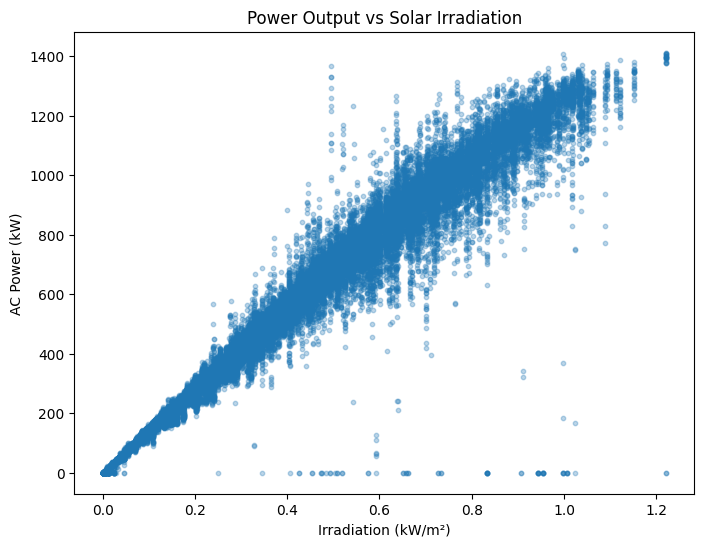

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['IRRADIATION'], df['AC_POWER'], alpha=0.3, s=10)
plt.xlabel('Irradiation (kW/m²)')
plt.ylabel('AC Power (kW)')
plt.title('Power Output vs Solar Irradiation')
plt.show()

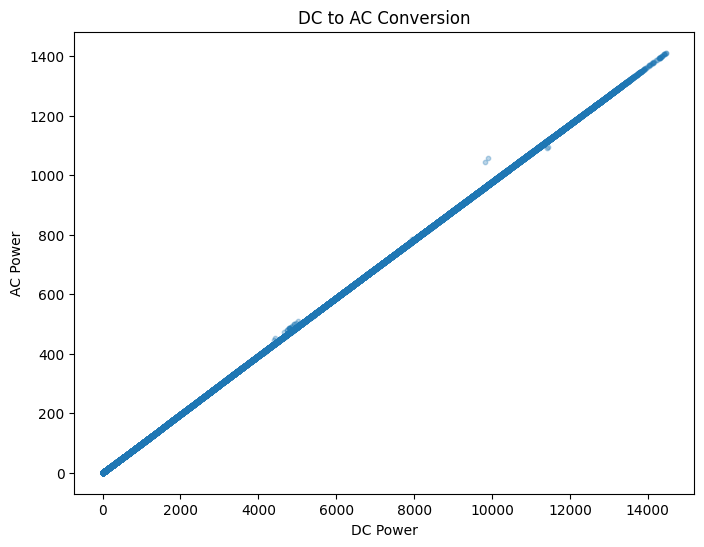

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df['DC_POWER'], df['AC_POWER'], alpha=0.3, s=10)
plt.xlabel('DC Power')
plt.ylabel('AC Power')
plt.title('DC to AC Conversion')
plt.show()

In [ ]:
df = df.drop(columns=['SOURCE_KEY_x'])

In [ ]:
df['year'] = df['DATE_TIME'].dt.year
df['month'] = df['DATE_TIME'].dt.month
df['day'] = df['DATE_TIME'].dt.day

In [ ]:
df['hour'] = df['DATE_TIME'].dt.hour
df['minute'] = df['DATE_TIME'].dt.minute

In [ ]:
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

df['temp_differential'] = df['MODULE_TEMPERATURE'] - df['AMBIENT_TEMPERATURE']

df['inverter_efficiency'] = df['AC_POWER'] / (df['DC_POWER'] + 0.001)

df['temp_derating'] = 1 - 0.004 * (df['MODULE_TEMPERATURE'] - 25)

df['power_per_irradiation'] = df['AC_POWER'] / (df['IRRADIATION'] + 0.001)
df['irradiation_temp'] = (
    df['IRRADIATION']
    * df['MODULE_TEMPERATURE']
)


In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

feature_cols = [
    'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
    'hour_sin', 'hour_cos', 'temp_differential', 'temp_derating'
]

X = df[feature_cols]
y = df['AC_POWER']

split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: MAE={mae:.2f} kW, R²={r2:.4f}")

tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(
    XGBRegressor(random_state=42), X, y,
    cv=tscv, scoring='neg_mean_absolute_error'
)
print(f"Time series CV MAE: {-scores.mean():.4f} ± {scores.std():.4f}")

Random Forest: MAE=17.57 kW, R²=0.9786
Gradient Boosting: MAE=16.84 kW, R²=0.9801
XGBoost: MAE=16.92 kW, R²=0.9789
Time series CV MAE: 21.4775 ± 2.5771


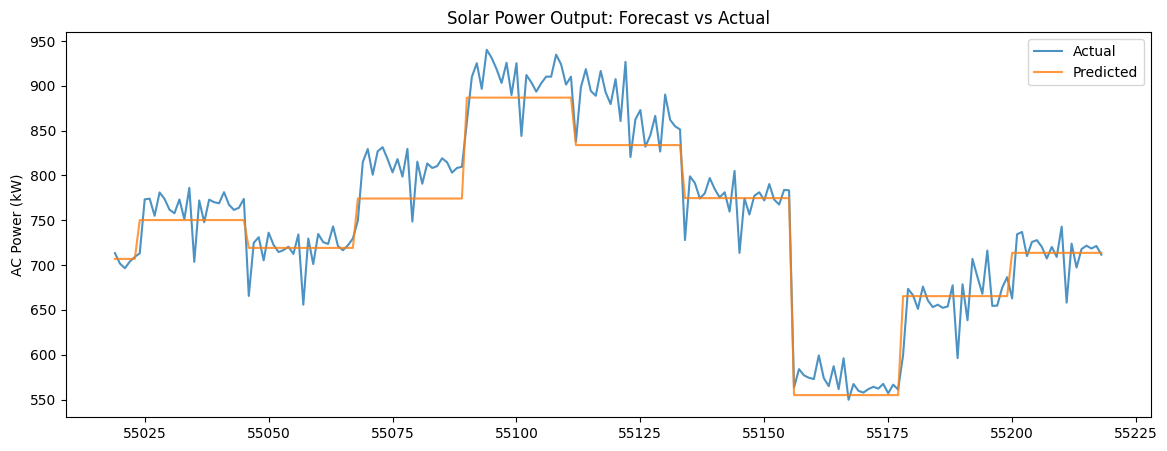

In [ ]:
df_test = df.iloc[split_point:].copy()
from sklearn.ensemble import GradientBoostingRegressor

best_model = GradientBoostingRegressor(
    random_state=42
)

best_model.fit(X_train, y_train)
df_test['predicted_power'] = best_model.predict(X_test)

plt.figure(figsize=(14, 5))
plt.plot(df_test.index[:200], df_test['AC_POWER'].values[:200], label='Actual', alpha=0.8)
plt.plot(df_test.index[:200], df_test['predicted_power'].values[:200], label='Predicted', alpha=0.8)
plt.title('Solar Power Output: Forecast vs Actual')
plt.ylabel('AC Power (kW)')
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

feature_cols = [
    'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
    'hour_sin', 'hour_cos', 'temp_differential', 'temp_derating'
]

X = df[feature_cols]
y = df['DC_POWER']

split_point = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]

models = {
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}: MAE={mae:.2f} kW, R²={r2:.4f}")

tscv = TimeSeriesSplit(n_splits=5)
scores = cross_val_score(
    XGBRegressor(random_state=42), X, y,
    cv=tscv, scoring='neg_mean_absolute_error'
)
print(f"Time series CV MAE: {-scores.mean():.4f} ± {scores.std():.4f}")

Random Forest: MAE=180.59 kW, R²=0.9784
Gradient Boosting: MAE=171.62 kW, R²=0.9801
XGBoost: MAE=171.96 kW, R²=0.9793
Time series CV MAE: 219.3580 ± 27.0846
